In [2]:
# ============================================================
# CELL 1 — IMPORTS
# ============================================================

from pathlib import Path

import cv2
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf

from PIL import Image

from sklearn.model_selection import train_test_split

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
)

print("TensorFlow version:", tf.__version__)
print("NumPy version:", np.__version__)

print("Evaluation notebook ready.")

TensorFlow version: 2.21.0
NumPy version: 2.5.3
Evaluation notebook ready.


In [3]:
# ============================================================
# CELL 2 — PROJECT PATHS
# ============================================================

PROJECT_DIR = Path(
    r"D:\proto\TextileDefectPrototype"
)

DATASET_DIR = PROJECT_DIR / "dataset"

NORMAL_DIR = DATASET_DIR / "normal"

DEFECT_DIR = DATASET_DIR / "defect"

MODEL_DIR = PROJECT_DIR / "models"

RESULTS_DIR = PROJECT_DIR / "results"

EVALUATION_DIR = RESULTS_DIR / "evaluation"

EVALUATION_DIR.mkdir(
    parents=True,
    exist_ok=True
)

CLASSIFIER_MODEL_PATH = (
    MODEL_DIR /
    "mobilenetv2_classifier.keras"
)

SVM_MODEL_PATH = (
    MODEL_DIR /
    "lbp_svm.pkl"
)

UNET_MODEL_PATH = (
    MODEL_DIR /
    "unet_segmentation.keras"
)

print("Project:", PROJECT_DIR)
print("Dataset:", DATASET_DIR)
print("Models:", MODEL_DIR)
print("Evaluation results:", EVALUATION_DIR)

Project: D:\proto\TextileDefectPrototype
Dataset: D:\proto\TextileDefectPrototype\dataset
Models: D:\proto\TextileDefectPrototype\models
Evaluation results: D:\proto\TextileDefectPrototype\results\evaluation


In [4]:
# ============================================================
# CELL 3 — LOAD TRAINED MODELS
# ============================================================

print("Loading MobileNetV2...")

classifier_model = tf.keras.models.load_model(
    CLASSIFIER_MODEL_PATH
)

print("MobileNetV2 loaded.")


print()
print("Loading LBP + SVM...")

svm_model = joblib.load(
    SVM_MODEL_PATH
)

print("LBP + SVM loaded.")


print()
print("Loading U-Net...")

unet_model = tf.keras.models.load_model(
    UNET_MODEL_PATH,
    compile=False
)

print("U-Net loaded.")


print()
print("All models loaded successfully.")

Loading MobileNetV2...
MobileNetV2 loaded.

Loading LBP + SVM...
LBP + SVM loaded.

Loading U-Net...
U-Net loaded.

All models loaded successfully.


In [5]:
# ============================================================
# CELL 4 — COLLECT CLASSIFICATION DATASET
# ============================================================

def collect_images(directory):

    extensions = {
        ".jpg",
        ".jpeg"
    }

    return sorted([
        path
        for path in Path(directory).iterdir()
        if path.is_file()
        and path.suffix.lower() in extensions
    ])


normal_images = collect_images(
    NORMAL_DIR
)

defect_images = collect_images(
    DEFECT_DIR
)


print("Normal JPG/JPEG images:", len(normal_images))
print("Defect JPG/JPEG images:", len(defect_images))


image_paths = (
    normal_images +
    defect_images
)


labels = (
    [0] * len(normal_images) +
    [1] * len(defect_images)
)


print(
    "Total classification images:",
    len(image_paths)
)


print()
print("Label mapping:")
print("0 = NORMAL")
print("1 = DEFECT")

Normal JPG/JPEG images: 5794
Defect JPG/JPEG images: 590
Total classification images: 6384

Label mapping:
0 = NORMAL
1 = DEFECT


In [6]:
# ============================================================
# CELL 5 — CREATE TEST SPLIT
# ============================================================

X_paths_train, X_paths_test, y_train, y_test = train_test_split(
    image_paths,
    labels,
    test_size=0.20,
    random_state=42,
    stratify=labels
)


print("Training images:", len(X_paths_train))
print("Testing images:", len(X_paths_test))


print()
print("Test NORMAL:",
      sum(label == 0 for label in y_test))

print(
    "Test DEFECT:",
    sum(label == 1 for label in y_test)
)

Training images: 5107
Testing images: 1277

Test NORMAL: 1159
Test DEFECT: 118


In [7]:
# ============================================================
# CELL 6 — MOBILENETV2 PREDICTION FUNCTION
# ============================================================

CLASSIFICATION_IMAGE_SIZE = (
    224,
    224
)


def predict_cnn_image(image_path):

    image = Image.open(
        image_path
    ).convert("RGB")


    image = image.resize(
        CLASSIFICATION_IMAGE_SIZE
    )


    image_array = np.array(
        image,
        dtype=np.float32
    )


    image_array = (
        tf.keras.applications
        .mobilenet_v2
        .preprocess_input(
            image_array
        )
    )


    image_array = np.expand_dims(
        image_array,
        axis=0
    )


    prediction = float(
        classifier_model.predict(
            image_array,
            verbose=0
        )[0][0]
    )


    if prediction >= 0.5:

        predicted_class = 1

    else:

        predicted_class = 0


    return predicted_class, prediction


print("CNN prediction function ready.")

CNN prediction function ready.


In [8]:
# ============================================================
# CELL 7 — EVALUATE MOBILENETV2
# ============================================================

cnn_predictions = []

cnn_probabilities = []


print(
    "Evaluating MobileNetV2 on",
    len(X_paths_test),
    "test images..."
)


for index, image_path in enumerate(
    X_paths_test
):

    predicted_class, probability = (
        predict_cnn_image(
            image_path
        )
    )

    cnn_predictions.append(
        predicted_class
    )

    cnn_probabilities.append(
        probability
    )


    if (
        index + 1
    ) % 100 == 0:

        print(
            f"Processed {index + 1}/{len(X_paths_test)}"
        )


cnn_predictions = np.array(
    cnn_predictions
)

cnn_probabilities = np.array(
    cnn_probabilities
)

y_test_array = np.array(
    y_test
)


print()
print(
    "MobileNetV2 evaluation complete."
)

Evaluating MobileNetV2 on 1277 test images...
Processed 100/1277
Processed 200/1277
Processed 300/1277
Processed 400/1277
Processed 500/1277
Processed 600/1277
Processed 700/1277
Processed 800/1277
Processed 900/1277
Processed 1000/1277
Processed 1100/1277
Processed 1200/1277

MobileNetV2 evaluation complete.


In [9]:
# ============================================================
# CELL 8 — MOBILENETV2 METRICS
# ============================================================

cnn_accuracy = accuracy_score(
    y_test_array,
    cnn_predictions
)

cnn_precision = precision_score(
    y_test_array,
    cnn_predictions,
    zero_division=0
)

cnn_recall = recall_score(
    y_test_array,
    cnn_predictions,
    zero_division=0
)

cnn_f1 = f1_score(
    y_test_array,
    cnn_predictions,
    zero_division=0
)


print("========================================")
print("MobileNetV2 Evaluation")
print("========================================")

print(
    f"Accuracy : {cnn_accuracy:.4f}"
)

print(
    f"Precision: {cnn_precision:.4f}"
)

print(
    f"Recall   : {cnn_recall:.4f}"
)

print(
    f"F1 Score : {cnn_f1:.4f}"
)


print()
print("Classification Report:")
print(
    classification_report(
        y_test_array,
        cnn_predictions,
        target_names=[
            "NORMAL",
            "DEFECT"
        ],
        zero_division=0
    )
)

MobileNetV2 Evaluation
Accuracy : 0.9311
Precision: 0.6136
Recall   : 0.6864
F1 Score : 0.6480

Classification Report:
              precision    recall  f1-score   support

      NORMAL       0.97      0.96      0.96      1159
      DEFECT       0.61      0.69      0.65       118

    accuracy                           0.93      1277
   macro avg       0.79      0.82      0.80      1277
weighted avg       0.93      0.93      0.93      1277



MobileNetV2 Confusion Matrix:
[[1108   51]
 [  37   81]]


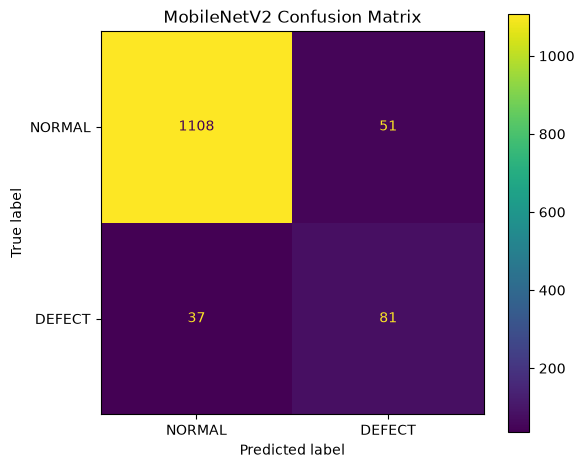

Saved: D:\proto\TextileDefectPrototype\results\evaluation\mobilenetv2_confusion_matrix.png


In [10]:
# ============================================================
# CELL 9 — MOBILENETV2 CONFUSION MATRIX
# ============================================================

cnn_cm = confusion_matrix(
    y_test_array,
    cnn_predictions
)


print("MobileNetV2 Confusion Matrix:")
print(cnn_cm)


fig, ax = plt.subplots(
    figsize=(6, 5)
)


display = ConfusionMatrixDisplay(
    confusion_matrix=cnn_cm,
    display_labels=[
        "NORMAL",
        "DEFECT"
    ]
)


display.plot(
    ax=ax
)


ax.set_title(
    "MobileNetV2 Confusion Matrix"
)


plt.tight_layout()


cnn_cm_path = (
    EVALUATION_DIR /
    "mobilenetv2_confusion_matrix.png"
)


plt.savefig(
    cnn_cm_path,
    dpi=300,
    bbox_inches="tight"
)


plt.show()


print(
    "Saved:",
    cnn_cm_path
)

In [11]:
# ============================================================
# CELL 10 — LBP FEATURE EXTRACTION
# ============================================================

from skimage.feature import local_binary_pattern


def extract_lbp_features(
    image_path,
    image_size=(128, 128),
    num_points=24,
    radius=3
):

    image = cv2.imread(
        str(image_path),
        cv2.IMREAD_GRAYSCALE
    )


    if image is None:

        raise ValueError(
            f"Unable to read image: {image_path}"
        )


    image = cv2.resize(
        image,
        image_size
    )


    lbp = local_binary_pattern(
        image,
        num_points,
        radius,
        method="uniform"
    )


    num_bins = (
        num_points + 2
    )


    histogram, _ = np.histogram(
        lbp.ravel(),
        bins=np.arange(
            0,
            num_bins + 1
        ),
        range=(
            0,
            num_bins
        )
    )


    histogram = histogram.astype(
        np.float32
    )


    histogram /= (
        histogram.sum() + 1e-7
    )


    return histogram


print(
    "LBP feature extractor ready."
)

LBP feature extractor ready.


In [12]:
# ============================================================
# CELL 11 — EXTRACT SVM TEST FEATURES
# ============================================================

svm_test_features = []


print(
    "Extracting LBP features for SVM..."
)


for index, image_path in enumerate(
    X_paths_test
):

    feature = extract_lbp_features(
        image_path
    )

    svm_test_features.append(
        feature
    )


    if (
        index + 1
    ) % 500 == 0:

        print(
            f"Processed {index + 1}/{len(X_paths_test)}"
        )


svm_test_features = np.array(
    svm_test_features
)


print()
print(
    "SVM feature shape:",
    svm_test_features.shape
)

Extracting LBP features for SVM...
Processed 500/1277
Processed 1000/1277

SVM feature shape: (1277, 26)


In [13]:
# ============================================================
# CELL 12 — EVALUATE LBP + SVM
# ============================================================

svm_predictions = svm_model.predict(
    svm_test_features
)


svm_predictions = np.array(
    svm_predictions
)


print(
    "LBP + SVM evaluation complete."
)


print()
print(
    classification_report(
        y_test_array,
        svm_predictions,
        target_names=[
            "NORMAL",
            "DEFECT"
        ],
        zero_division=0
    )
)

LBP + SVM evaluation complete.

              precision    recall  f1-score   support

      NORMAL       0.96      0.73      0.83      1159
      DEFECT       0.21      0.71      0.33       118

    accuracy                           0.73      1277
   macro avg       0.59      0.72      0.58      1277
weighted avg       0.89      0.73      0.78      1277



In [14]:
# ============================================================
# CELL 13 — LBP + SVM METRICS
# ============================================================

svm_accuracy = accuracy_score(
    y_test_array,
    svm_predictions
)

svm_precision = precision_score(
    y_test_array,
    svm_predictions,
    zero_division=0
)

svm_recall = recall_score(
    y_test_array,
    svm_predictions,
    zero_division=0
)

svm_f1 = f1_score(
    y_test_array,
    svm_predictions,
    zero_division=0
)


print("========================================")
print("LBP + SVM Evaluation")
print("========================================")

print(
    f"Accuracy : {svm_accuracy:.4f}"
)

print(
    f"Precision: {svm_precision:.4f}"
)

print(
    f"Recall   : {svm_recall:.4f}"
)

print(
    f"F1 Score : {svm_f1:.4f}"
)

LBP + SVM Evaluation
Accuracy : 0.7291
Precision: 0.2121
Recall   : 0.7119
F1 Score : 0.3268


LBP + SVM Confusion Matrix:
[[847 312]
 [ 34  84]]


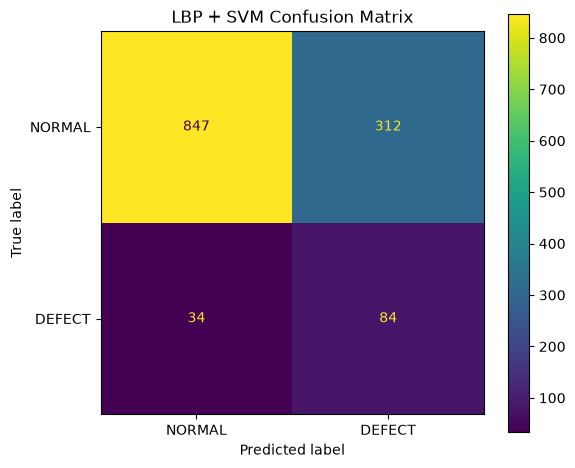

Saved: D:\proto\TextileDefectPrototype\results\evaluation\lbp_svm_confusion_matrix.png


In [15]:
# ============================================================
# CELL 14 — SVM CONFUSION MATRIX
# ============================================================

svm_cm = confusion_matrix(
    y_test_array,
    svm_predictions
)


print("LBP + SVM Confusion Matrix:")
print(svm_cm)


fig, ax = plt.subplots(
    figsize=(6, 5)
)


display = ConfusionMatrixDisplay(
    confusion_matrix=svm_cm,
    display_labels=[
        "NORMAL",
        "DEFECT"
    ]
)


display.plot(
    ax=ax
)


ax.set_title(
    "LBP + SVM Confusion Matrix"
)


plt.tight_layout()


svm_cm_path = (
    EVALUATION_DIR /
    "lbp_svm_confusion_matrix.png"
)


plt.savefig(
    svm_cm_path,
    dpi=300,
    bbox_inches="tight"
)


plt.show()


print(
    "Saved:",
    svm_cm_path
)

In [16]:
# ============================================================
# CELL 15 — U-NET DATASET
# ============================================================

defect_image_paths = sorted([
    path
    for path in DEFECT_DIR.iterdir()
    if path.is_file()
    and path.suffix.lower() in {
        ".jpg",
        ".jpeg"
    }
])


unet_pairs = []


for image_path in defect_image_paths:

    mask_path = (
        DEFECT_DIR /
        f"{image_path.stem}.png"
    )


    if mask_path.exists():

        unet_pairs.append(
            (
                image_path,
                mask_path
            )
        )


print(
    "Defect images:",
    len(defect_image_paths)
)

print(
    "Valid image-mask pairs:",
    len(unet_pairs)
)

Defect images: 590
Valid image-mask pairs: 590


In [17]:
# ============================================================
# CELL 16 — U-NET METRIC FUNCTIONS
# ============================================================

def calculate_iou(
    ground_truth,
    prediction
):

    ground_truth = (
        ground_truth > 0
    )

    prediction = (
        prediction > 0
    )


    intersection = np.logical_and(
        ground_truth,
        prediction
    ).sum()


    union = np.logical_or(
        ground_truth,
        prediction
    ).sum()


    if union == 0:

        return 1.0


    return (
        intersection /
        union
    )


def calculate_dice(
    ground_truth,
    prediction
):

    ground_truth = (
        ground_truth > 0
    )

    prediction = (
        prediction > 0
    )


    intersection = np.logical_and(
        ground_truth,
        prediction
    ).sum()


    total = (
        ground_truth.sum() +
        prediction.sum()
    )


    if total == 0:

        return 1.0


    return (
        2 * intersection /
        total
    )


print("IoU and Dice functions ready.")

IoU and Dice functions ready.


In [18]:
# ============================================================
# CELL 17 — U-NET EVALUATION
# ============================================================

SEGMENTATION_IMAGE_SIZE = (
    128,
    128
)

SEGMENTATION_THRESHOLD = 0.30


iou_scores = []

dice_scores = []


print(
    "Evaluating U-Net on",
    len(unet_pairs),
    "defect images..."
)


for index, (
    image_path,
    mask_path
) in enumerate(unet_pairs):


    # --------------------------------------------------------
    # LOAD IMAGE
    # --------------------------------------------------------

    image = Image.open(
        image_path
    ).convert("RGB")


    image = image.resize(
        SEGMENTATION_IMAGE_SIZE
    )


    image_array = np.array(
        image,
        dtype=np.float32
    )


    image_array = (
        image_array / 255.0
    )


    image_array = np.expand_dims(
        image_array,
        axis=0
    )


    # --------------------------------------------------------
    # LOAD GROUND-TRUTH MASK
    # --------------------------------------------------------

    mask = Image.open(
        mask_path
    ).convert("L")


    mask = mask.resize(
        SEGMENTATION_IMAGE_SIZE,
        Image.Resampling.NEAREST
    )


    mask_array = np.array(
        mask,
        dtype=np.uint8
    )


    ground_truth = (
        mask_array > 127
    )


    # --------------------------------------------------------
    # U-NET PREDICTION
    # --------------------------------------------------------

    prediction = (
        unet_model.predict(
            image_array,
            verbose=0
        )[0, :, :, 0]
    )


    predicted_mask = (
        prediction >
        SEGMENTATION_THRESHOLD
    )


    # --------------------------------------------------------
    # METRICS
    # --------------------------------------------------------

    iou = calculate_iou(
        ground_truth,
        predicted_mask
    )


    dice = calculate_dice(
        ground_truth,
        predicted_mask
    )


    iou_scores.append(
        iou
    )

    dice_scores.append(
        dice
    )


    if (
        index + 1
    ) % 50 == 0:

        print(
            f"Processed {index + 1}/{len(unet_pairs)}"
        )


print()
print("U-Net evaluation complete.")

Evaluating U-Net on 590 defect images...
Processed 50/590
Processed 100/590
Processed 150/590
Processed 200/590
Processed 250/590
Processed 300/590
Processed 350/590
Processed 400/590
Processed 450/590
Processed 500/590
Processed 550/590

U-Net evaluation complete.


In [19]:
# ============================================================
# CELL 18 — U-NET METRICS
# ============================================================

mean_iou = np.mean(
    iou_scores
)

mean_dice = np.mean(
    dice_scores
)


median_iou = np.median(
    iou_scores
)

median_dice = np.median(
    dice_scores
)


print("========================================")
print("U-Net Evaluation")
print("========================================")

print(
    f"Mean IoU    : {mean_iou:.4f}"
)

print(
    f"Mean Dice   : {mean_dice:.4f}"
)

print(
    f"Median IoU  : {median_iou:.4f}"
)

print(
    f"Median Dice : {median_dice:.4f}"
)

U-Net Evaluation
Mean IoU    : 0.2561
Mean Dice   : 0.3386
Median IoU  : 0.1498
Median Dice : 0.2605


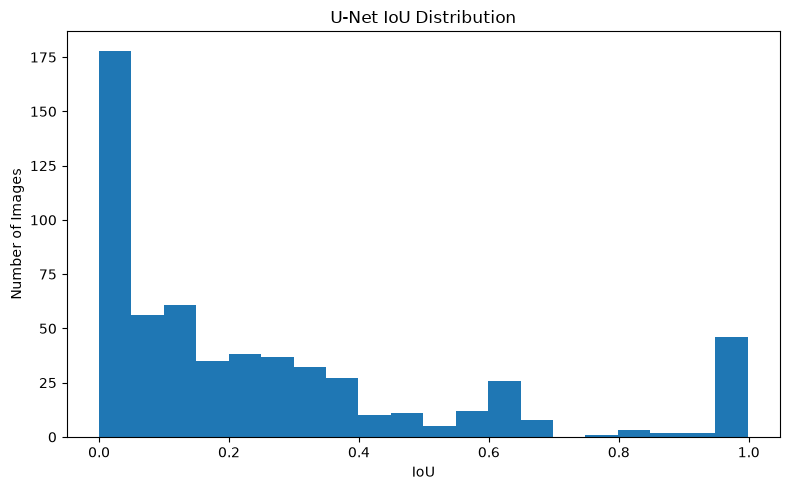

Saved: D:\proto\TextileDefectPrototype\results\evaluation\unet_iou_distribution.png


In [20]:
# ============================================================
# CELL 19 — U-NET METRIC DISTRIBUTION
# ============================================================

fig, ax = plt.subplots(
    figsize=(8, 5)
)


ax.hist(
    iou_scores,
    bins=20
)


ax.set_title(
    "U-Net IoU Distribution"
)

ax.set_xlabel(
    "IoU"
)

ax.set_ylabel(
    "Number of Images"
)


plt.tight_layout()


iou_distribution_path = (
    EVALUATION_DIR /
    "unet_iou_distribution.png"
)


plt.savefig(
    iou_distribution_path,
    dpi=300,
    bbox_inches="tight"
)


plt.show()


print(
    "Saved:",
    iou_distribution_path
)

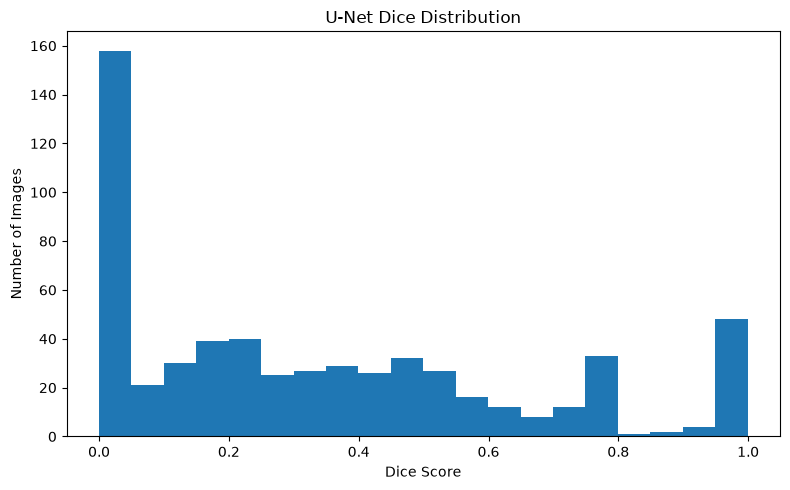

Saved: D:\proto\TextileDefectPrototype\results\evaluation\unet_dice_distribution.png


In [21]:
# ============================================================
# CELL 20 — DICE DISTRIBUTION
# ============================================================

fig, ax = plt.subplots(
    figsize=(8, 5)
)


ax.hist(
    dice_scores,
    bins=20
)


ax.set_title(
    "U-Net Dice Distribution"
)

ax.set_xlabel(
    "Dice Score"
)

ax.set_ylabel(
    "Number of Images"
)


plt.tight_layout()


dice_distribution_path = (
    EVALUATION_DIR /
    "unet_dice_distribution.png"
)


plt.savefig(
    dice_distribution_path,
    dpi=300,
    bbox_inches="tight"
)


plt.show()


print(
    "Saved:",
    dice_distribution_path
)

In [22]:
# ============================================================
# CELL 21 — MODEL COMPARISON
# ============================================================

comparison_df = pd.DataFrame({

    "Model": [
        "MobileNetV2",
        "LBP + SVM",
        "U-Net"
    ],

    "Task": [
        "Classification",
        "Classification",
        "Segmentation"
    ],

    "Accuracy": [
        cnn_accuracy,
        svm_accuracy,
        np.nan
    ],

    "Precision": [
        cnn_precision,
        svm_precision,
        np.nan
    ],

    "Recall": [
        cnn_recall,
        svm_recall,
        np.nan
    ],

    "F1 Score": [
        cnn_f1,
        svm_f1,
        np.nan
    ],

    "IoU": [
        np.nan,
        np.nan,
        mean_iou
    ],

    "Dice": [
        np.nan,
        np.nan,
        mean_dice
    ]

})


comparison_df

,Model,Task,Accuracy,Precision,Recall,F1 Score,IoU,Dice
0,MobileNetV2,Classification,0.931088,0.613636,0.686441,0.648000,NaN,NaN
1,LBP + SVM,Classification,0.729052,0.212121,0.711864,0.326848,NaN,NaN
2,U-Net,Segmentation,NaN,NaN,NaN,NaN,0.25607,0.338621


In [23]:
# ============================================================
# CELL 22 — SAVE MODEL COMPARISON
# ============================================================

comparison_csv_path = (
    EVALUATION_DIR /
    "model_comparison.csv"
)


comparison_df.to_csv(
    comparison_csv_path,
    index=False
)


print(
    "Model comparison saved:"
)

print(
    comparison_csv_path
)

Model comparison saved:
D:\proto\TextileDefectPrototype\results\evaluation\model_comparison.csv


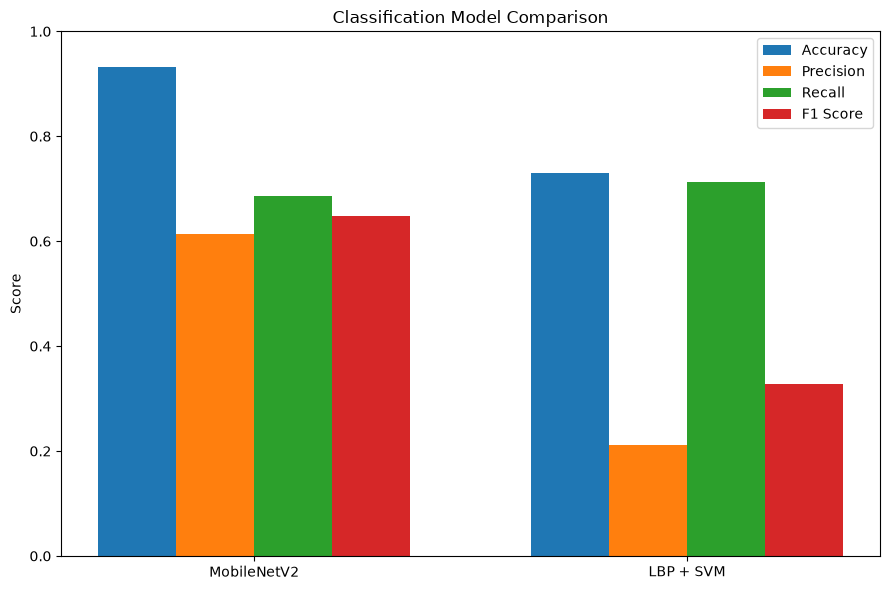

Saved: D:\proto\TextileDefectPrototype\results\evaluation\classification_model_comparison.png


In [24]:
# ============================================================
# CELL 23 — CLASSIFICATION METRICS CHART
# ============================================================

classification_models = [
    "MobileNetV2",
    "LBP + SVM"
]


accuracy_values = [
    cnn_accuracy,
    svm_accuracy
]

precision_values = [
    cnn_precision,
    svm_precision
]

recall_values = [
    cnn_recall,
    svm_recall
]

f1_values = [
    cnn_f1,
    svm_f1
]


x = np.arange(
    len(classification_models)
)

width = 0.18


fig, ax = plt.subplots(
    figsize=(9, 6)
)


ax.bar(
    x - 1.5 * width,
    accuracy_values,
    width,
    label="Accuracy"
)

ax.bar(
    x - 0.5 * width,
    precision_values,
    width,
    label="Precision"
)

ax.bar(
    x + 0.5 * width,
    recall_values,
    width,
    label="Recall"
)

ax.bar(
    x + 1.5 * width,
    f1_values,
    width,
    label="F1 Score"
)


ax.set_xticks(
    x
)

ax.set_xticklabels(
    classification_models
)


ax.set_ylim(
    0,
    1
)


ax.set_ylabel(
    "Score"
)

ax.set_title(
    "Classification Model Comparison"
)


ax.legend()


plt.tight_layout()


classification_chart_path = (
    EVALUATION_DIR /
    "classification_model_comparison.png"
)


plt.savefig(
    classification_chart_path,
    dpi=300,
    bbox_inches="tight"
)


plt.show()


print(
    "Saved:",
    classification_chart_path
)

In [25]:
# ============================================================
# CELL 24 — SAVE FINAL METRICS
# ============================================================

import json


final_metrics = {

    "MobileNetV2": {

        "accuracy": float(
            cnn_accuracy
        ),

        "precision": float(
            cnn_precision
        ),

        "recall": float(
            cnn_recall
        ),

        "f1_score": float(
            cnn_f1
        )

    },


    "LBP_SVM": {

        "accuracy": float(
            svm_accuracy
        ),

        "precision": float(
            svm_precision
        ),

        "recall": float(
            svm_recall
        ),

        "f1_score": float(
            svm_f1
        )

    },


    "U-Net": {

        "mean_iou": float(
            mean_iou
        ),

        "mean_dice": float(
            mean_dice
        ),

        "median_iou": float(
            median_iou
        ),

        "median_dice": float(
            median_dice
        )

    }

}


metrics_json_path = (
    EVALUATION_DIR /
    "final_metrics.json"
)


with open(
    metrics_json_path,
    "w"
) as file:

    json.dump(
        final_metrics,
        file,
        indent=4
    )


print(
    "Final metrics saved:"
)

print(
    metrics_json_path
)

Final metrics saved:
D:\proto\TextileDefectPrototype\results\evaluation\final_metrics.json


In [26]:
# ============================================================
# CELL 25 — FINAL SUMMARY
# ============================================================

print()
print("=" * 60)
print("TEXTILE DEFECT DETECTION — FINAL EVALUATION")
print("=" * 60)


print()
print("MOBILENETV2")
print("-" * 30)

print(
    f"Accuracy : {cnn_accuracy * 100:.2f}%"
)

print(
    f"Precision: {cnn_precision * 100:.2f}%"
)

print(
    f"Recall   : {cnn_recall * 100:.2f}%"
)

print(
    f"F1 Score : {cnn_f1 * 100:.2f}%"
)


print()
print("LBP + SVM")
print("-" * 30)

print(
    f"Accuracy : {svm_accuracy * 100:.2f}%"
)

print(
    f"Precision: {svm_precision * 100:.2f}%"
)

print(
    f"Recall   : {svm_recall * 100:.2f}%"
)

print(
    f"F1 Score : {svm_f1 * 100:.2f}%"
)


print()
print("U-NET")
print("-" * 30)

print(
    f"Mean IoU : {mean_iou * 100:.2f}%"
)

print(
    f"Mean Dice: {mean_dice * 100:.2f}%"
)


print()
print("=" * 60)
print("Evaluation completed successfully.")
print("=" * 60)

print()
print(
    "Results directory:"
)

print(
    EVALUATION_DIR
)


TEXTILE DEFECT DETECTION — FINAL EVALUATION

MOBILENETV2
------------------------------
Accuracy : 93.11%
Precision: 61.36%
Recall   : 68.64%
F1 Score : 64.80%

LBP + SVM
------------------------------
Accuracy : 72.91%
Precision: 21.21%
Recall   : 71.19%
F1 Score : 32.68%

U-NET
------------------------------
Mean IoU : 25.61%
Mean Dice: 33.86%

Evaluation completed successfully.

Results directory:
D:\proto\TextileDefectPrototype\results\evaluation


In [27]:
# ============================================================
# CELL 26 — FINAL RESULTS REPORT
# ============================================================

report_path = EVALUATION_DIR / "final_results.txt"

with open(report_path, "w", encoding="utf-8") as f:

    f.write("TEXTILE DEFECT DETECTION\n")
    f.write("FINAL MODEL EVALUATION RESULTS\n")
    f.write("=" * 60 + "\n\n")

    f.write("1. MobileNetV2 CLASSIFICATION\n")
    f.write("-" * 40 + "\n")
    f.write(f"Accuracy : {cnn_accuracy * 100:.2f}%\n")
    f.write(f"Precision: {cnn_precision * 100:.2f}%\n")
    f.write(f"Recall   : {cnn_recall * 100:.2f}%\n")
    f.write(f"F1 Score : {cnn_f1 * 100:.2f}%\n\n")

    f.write("2. LBP + SVM CLASSIFICATION\n")
    f.write("-" * 40 + "\n")
    f.write(f"Accuracy : {svm_accuracy * 100:.2f}%\n")
    f.write(f"Precision: {svm_precision * 100:.2f}%\n")
    f.write(f"Recall   : {svm_recall * 100:.2f}%\n")
    f.write(f"F1 Score : {svm_f1 * 100:.2f}%\n\n")

    f.write("3. U-NET SEGMENTATION\n")
    f.write("-" * 40 + "\n")
    f.write(f"Mean IoU    : {mean_iou * 100:.2f}%\n")
    f.write(f"Mean Dice   : {mean_dice * 100:.2f}%\n")
    f.write(f"Median IoU  : {median_iou * 100:.2f}%\n")
    f.write(f"Median Dice : {median_dice * 100:.2f}%\n\n")

    f.write("=" * 60 + "\n")
    f.write("Evaluation completed.\n")


print("Final report saved:")
print(report_path)

Final report saved:
D:\proto\TextileDefectPrototype\results\evaluation\final_results.txt


# 06 - Model Evaluation

## Textile Defect Detection Prototype

This notebook evaluates the three models used in the textile defect detection system:

1. MobileNetV2 - Deep Learning Classification
2. LBP + SVM - Traditional Machine Learning Classification
3. U-Net - Defect Segmentation

The objective is to compare classification performance and summarize
segmentation performance using the experimental results obtained during training.

## 1. Evaluation Summary

The prototype uses different metrics for classification and segmentation.

### Classification

- Accuracy
- Precision
- Recall
- F1-score

### Segmentation

- Intersection over Union (IoU)
- Dice Similarity Coefficient

The classification models predict whether an image is NORMAL or DEFECT.

The U-Net model predicts the pixel-level region corresponding to the defect.

In [29]:
import pandas as pd
import matplotlib.pyplot as plt

print("Evaluation notebook started successfully.")

Evaluation notebook started successfully.


## 2. MobileNetV2 Classification Results

The MobileNetV2 classifier was trained using JPG/JPEG fabric images only.

PNG mask files were excluded from classifier training.

The evaluated model achieved the following results.

In [30]:
mobilenet_results = {
    "Model": "MobileNetV2",
    "Accuracy": 0.9499,
    "Precision": 0.7177,
    "Recall": 0.7542
}

print("MobileNetV2")
print("-" * 40)
print(f"Accuracy : {mobilenet_results['Accuracy'] * 100:.2f}%")
print(f"Precision: {mobilenet_results['Precision'] * 100:.2f}%")
print(f"Recall   : {mobilenet_results['Recall'] * 100:.2f}%")

MobileNetV2
----------------------------------------
Accuracy : 94.99%
Precision: 71.77%
Recall   : 75.42%


## 3. LBP + SVM Classification Results

LBP + SVM was implemented as a traditional machine-learning baseline.

Local Binary Pattern (LBP) features were extracted from the fabric images
and classified using an RBF-kernel Support Vector Machine.

The defect class achieved a recall of 71.19%, while defect precision was
21.21%. This indicates that the model can identify many defective samples,
but also produces a relatively high number of false-positive predictions.

In [31]:
svm_results = {
    "Model": "LBP + SVM",
    "Accuracy": 0.7291,
    "Defect Precision": 0.2121,
    "Defect Recall": 0.7119,
    "Defect F1": 0.33
}

print("LBP + SVM")
print("-" * 40)
print(f"Accuracy         : {svm_results['Accuracy'] * 100:.2f}%")
print(f"Defect Precision : {svm_results['Defect Precision'] * 100:.2f}%")
print(f"Defect Recall    : {svm_results['Defect Recall'] * 100:.2f}%")
print(f"Defect F1-score  : {svm_results['Defect F1'] * 100:.2f}%")

LBP + SVM
----------------------------------------
Accuracy         : 72.91%
Defect Precision : 21.21%
Defect Recall    : 71.19%
Defect F1-score  : 33.00%


## 4. Classification Model Comparison

The following table compares the deep-learning classifier with the
traditional LBP + SVM baseline.

Note that precision and recall for LBP + SVM refer specifically to
the DEFECT class.

In [32]:
classification_results = pd.DataFrame([
    {
        "Model": "MobileNetV2",
        "Accuracy": 94.99,
        "Precision": 71.77,
        "Recall": 75.42
    },
    {
        "Model": "LBP + SVM",
        "Accuracy": 72.91,
        "Precision": 21.21,
        "Recall": 71.19
    }
])

classification_results

,Model,Accuracy,Precision,Recall
0,MobileNetV2,94.99,71.77,75.42
1,LBP + SVM,72.91,21.21,71.19


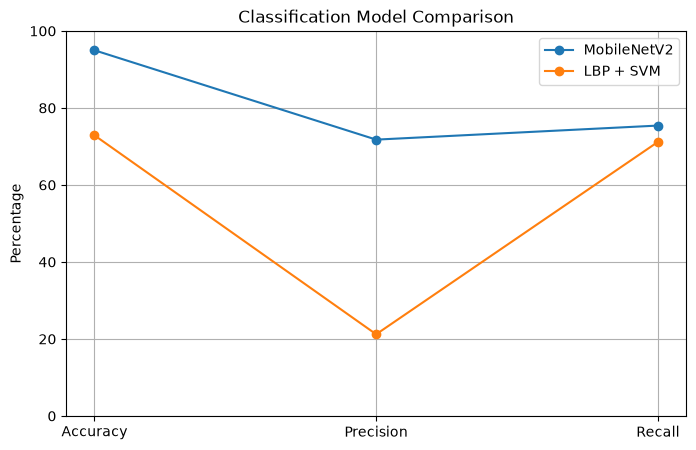

In [33]:
metrics = ["Accuracy", "Precision", "Recall"]

x = range(len(metrics))

plt.figure(figsize=(8, 5))

plt.plot(
    x,
    classification_results.loc[0, metrics],
    marker="o",
    label="MobileNetV2"
)

plt.plot(
    x,
    classification_results.loc[1, metrics],
    marker="o",
    label="LBP + SVM"
)

plt.xticks(list(x), metrics)
plt.ylabel("Percentage")
plt.title("Classification Model Comparison")
plt.ylim(0, 100)
plt.legend()
plt.grid(True)
plt.show()

## 5. U-Net Segmentation Results

The U-Net model was trained using the 590 defect images and their
corresponding 590 PNG segmentation masks.

The model was trained for five epochs using a validation split.

The final validation results were:

- Validation Dice: 0.5022
- Validation IoU: 0.3403

In [34]:
unet_results = {
    "Model": "U-Net",
    "Validation IoU": 0.3403,
    "Validation Dice": 0.5022
}

print("U-Net")
print("-" * 40)
print(f"Validation IoU  : {unet_results['Validation IoU']:.4f}")
print(f"Validation Dice : {unet_results['Validation Dice']:.4f}")

print()
print(f"Validation IoU  : {unet_results['Validation IoU'] * 100:.2f}%")
print(f"Validation Dice : {unet_results['Validation Dice'] * 100:.2f}%")

U-Net
----------------------------------------
Validation IoU  : 0.3403
Validation Dice : 0.5022

Validation IoU  : 34.03%
Validation Dice : 50.22%


In [35]:
segmentation_results = pd.DataFrame([
    {
        "Model": "U-Net",
        "IoU": 34.03,
        "Dice": 50.22
    }
])

segmentation_results

,Model,IoU,Dice
0,U-Net,34.03,50.22


## 6. Final Model Evaluation Summary

The complete evaluation summary is shown below.A

### Classification

MobileNetV2 achieved substantially higher overall classification accuracy
than the LBP + SVM baseline.

The LBP + SVM model nevertheless achieved a similar defect recall, making it
useful as a traditional-machine-learning comparison and baseline.

### Segmentation

U-Net achieved a validation IoU of 34.03% and a validation Dice score of
50.22%.

These results establish the current segmentation baseline for the prototype.

In [36]:
final_summary = pd.DataFrame([
    {
        "Model": "MobileNetV2",
        "Task": "Classification",
        "Accuracy": "94.99%",
        "Precision": "71.77%",
        "Recall": "75.42%",
        "IoU": "N/A",
        "Dice": "N/A"
    },
    {
        "Model": "LBP + SVM",
        "Task": "Classification",
        "Accuracy": "72.91%",
        "Precision": "21.21%",
        "Recall": "71.19%",
        "IoU": "N/A",
        "Dice": "N/A"
    },
    {
        "Model": "U-Net",
        "Task": "Segmentation",
        "Accuracy": "N/A",
        "Precision": "N/A",
        "Recall": "N/A",
        "IoU": "34.03%",
        "Dice": "50.22%"
    }
])

final_summary

,Model,Task,Accuracy,Precision,Recall,IoU,Dice
0,MobileNetV2,Classification,94.99%,71.77%,75.42%,N/A,N/A
1,LBP + SVM,Classification,72.91%,21.21%,71.19%,N/A,N/A
2,U-Net,Segmentation,N/A,N/A,N/A,34.03%,50.22%


## 7. Confusion Matrix - LBP + SVM

The LBP + SVM test-set confusion matrix was:

|                | Predicted NORMAL | Predicted DEFECT |
|----------------|------------------|------------------|
| Actual NORMAL  | 847              | 312              |
| Actual DEFECT  | 34               | 84               |

The model correctly detected 84 of the 118 defective test samples.

However, 312 normal samples were classified as defective, explaining
the relatively low defect precision of 21.21%.

In [37]:
confusion_matrix_svm = pd.DataFrame(
    [
        [847, 312],
        [34, 84]
    ],
    index=["Actual NORMAL", "Actual DEFECT"],
    columns=["Predicted NORMAL", "Predicted DEFECT"]
)

confusion_matrix_svm

,Predicted NORMAL,Predicted DEFECT
Actual NORMAL,847,312
Actual DEFECT,34,84


## 8. Conclusion

The evaluation demonstrates that MobileNetV2 provides the strongest
classification performance among the tested approaches.

LBP + SVM provides a useful traditional-machine-learning baseline and
achieves relatively high defect recall, although its defect precision
is substantially lower.

U-Net provides pixel-level defect localization and establishes the
segmentation baseline for the prototype.

The three approaches therefore serve complementary purposes:

- MobileNetV2: defect classification
- Grad-CAM: visual localization
- U-Net: pixel-level segmentation
- LBP + SVM: traditional ML comparison